# Network analysis for Bitcoin OTC data 

Dataset description : This is who-trusts-whom network of people who trade using Bitcoin on a platform called Bitcoin OTC. Since Bitcoin users are anonymous, there is a need to maintain a record of users' reputation to prevent transactions with fraudulent and risky users. Members of Bitcoin OTC rate other members in a scale of -10 (total distrust) to +10 (total trust) in steps of 1

Column names : 
SOURCE, TARGET, RATING, TIME
where
SOURCE: node id of source, i.e., rater
TARGET: node id of target, i.e., ratee
RATING: the source's rating for the target, ranging from -10 to +10 in steps of 1
TIME: the time of the rating, measured as seconds since Epoch.


Project description : 

### STEP 1 : Exploring the dataset 


In [4]:

import pandas as pd
import networkx as nx
from datetime import datetime

# Load the dataset
file_path = '/Users/arpitalonakadi/Downloads/soc-sign-bitcoinotc.csv.gz'  
columns = ['SOURCE', 'TARGET', 'RATING', 'TIME']
df = pd.read_csv(file_path, sep=',', names=columns, header=None)

# Convert TIME to a datetime format
df['TIME'] = pd.to_datetime(df['TIME'], unit='s')

# Split TIME into DATE and TIME columns
df['DATE'] = df['TIME'].dt.date
df['TIME'] = df['TIME'].dt.time.apply(lambda x: x.strftime('%H:%M:%S'))

# Display the first few rows to understand the data structure
print(df.head(40))

# Create a directed graph
G = nx.DiGraph()

# Add edges from the dataframe, using SOURCE as the start node and TARGET as the end node
for index, row in df.iterrows():
    source = row['SOURCE']
    target = row['TARGET']
    rating = row['RATING']
    
    # Add edge with the rating as the weight
    G.add_edge(source, target, weight=rating)

# Display basic information about the graph
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

# Display the first few edges with weights to verify
print("Sample edges with weights:")
for edge in list(G.edges(data=True))[:10]:
    print(edge)

    SOURCE  TARGET  RATING      TIME        DATE
0        6       2       4  18:45:11  2010-11-08
1        6       5       2  18:45:41  2010-11-08
2        1      15       1  19:05:40  2010-11-08
3        4       3       7  19:41:17  2010-11-08
4       13      16       8  22:10:54  2010-11-08
5       13      10       8  22:11:40  2010-11-08
6        7       5       1  04:18:20  2010-11-10
7        2      21       5  06:29:16  2010-11-10
8        2      20       5  06:30:22  2010-11-10
9       21       2       5  09:23:01  2010-11-10
10      21       1       8  02:10:11  2010-11-11
11      21      10       8  02:10:38  2010-11-11
12      21       8       9  02:10:50  2010-11-11
13      21       3       7  02:12:05  2010-11-11
14      17       3       5  02:25:13  2010-11-11
15      17      23       1  15:34:28  2010-11-11
16      10       1       8  09:54:16  2010-11-12
17      10       6       7  09:55:31  2010-11-12
18      10      21       8  09:55:45  2010-11-12
19      10       8  

The dataset was loaded, preprocessed, and transformed into a directed graph with 5,881 nodes and 35,592 weighted edges, representing user trust relationships for further analysis and visualization.


Basic Information about the Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35592 entries, 0 to 35591
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   SOURCE  35592 non-null  int64 
 1   TARGET  35592 non-null  int64 
 2   RATING  35592 non-null  int64 
 3   TIME    35592 non-null  object
 4   DATE    35592 non-null  object
dtypes: int64(3), object(2)
memory usage: 1.4+ MB
None

Summary Statistics:
             SOURCE        TARGET        RATING
count  35592.000000  35592.000000  35592.000000
mean    2353.847269   2417.478254      1.012025
std     1605.771178   1658.232170      3.562094
min        1.000000      1.000000    -10.000000
25%      988.000000    978.000000      1.000000
50%     2125.000000   2178.000000      1.000000
75%     3722.000000   3804.000000      2.000000
max     6000.000000   6005.000000     10.000000

Missing Values:
SOURCE    0
TARGET    0
RATING    0
TIME      0
DATE      0
dtype: int64

Number 

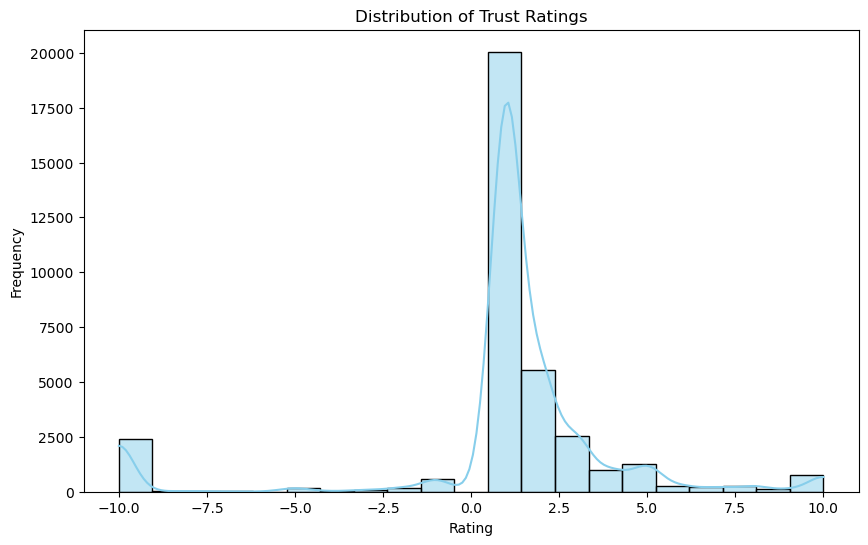

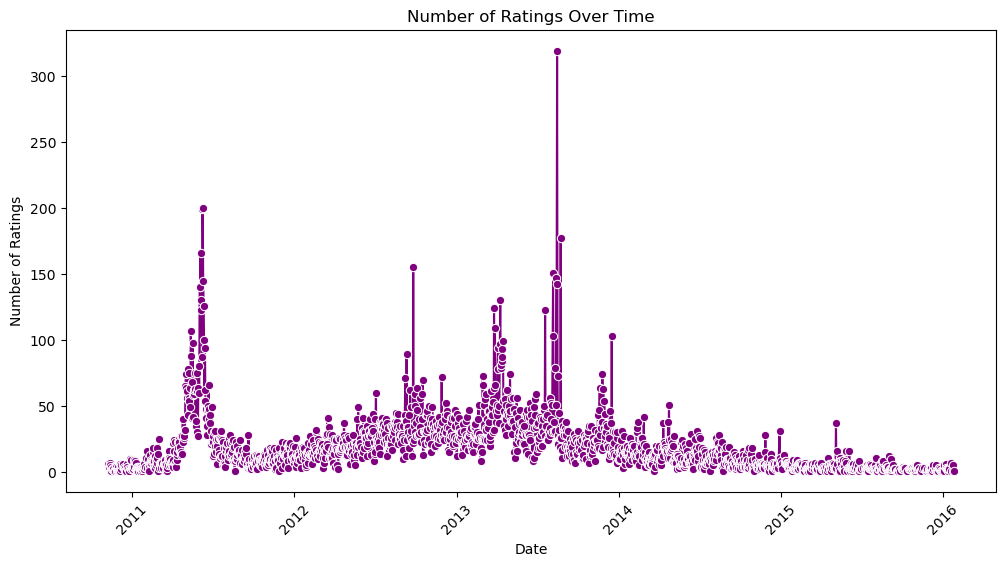

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_78942/204404510.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_sources.index, y=top_sources.values, palette='viridis')


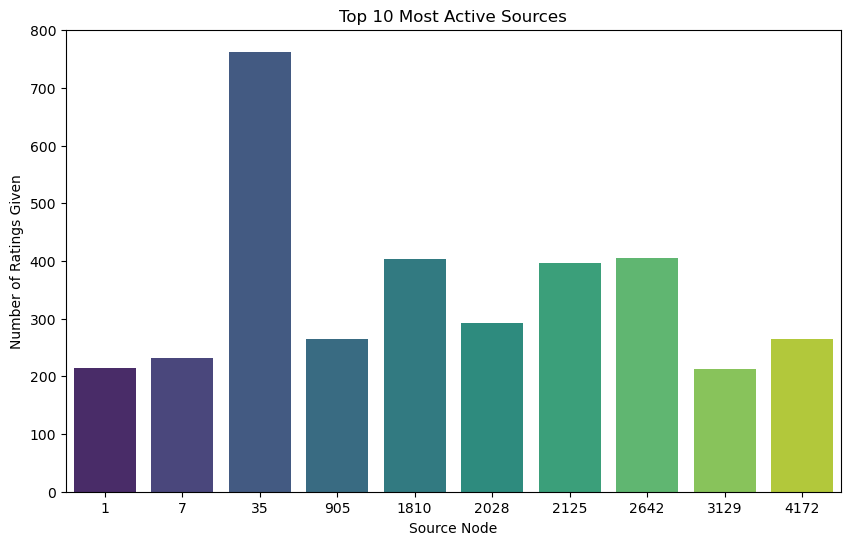

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_78942/204404510.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_targets.index, y=top_targets.values, palette='magma')


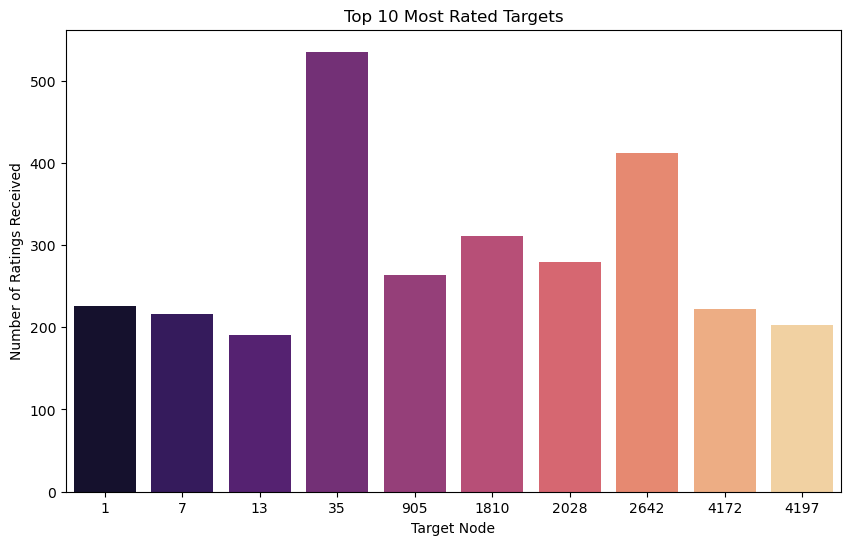

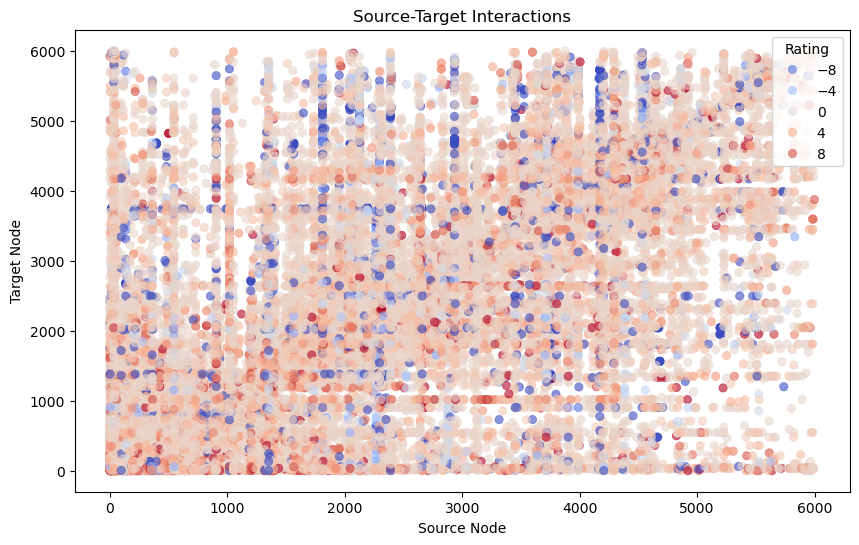

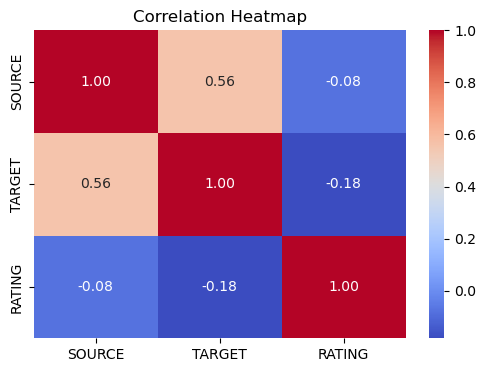

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/Users/arpitalonakadi/Downloads/soc-sign-bitcoinotc.csv.gz'  
columns = ['SOURCE', 'TARGET', 'RATING', 'TIME']
df = pd.read_csv(file_path, names=columns, header=None)

# Convert TIME to datetime and split into date and time
df['TIME'] = pd.to_datetime(df['TIME'], unit='s')
df['DATE'] = df['TIME'].dt.date
df['TIME'] = df['TIME'].dt.time.apply(lambda x: x.strftime('%H:%M:%S'))

# Display basic statistics
print("Basic Information about the Data:")
print(df.info())
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

# Distribution of Trust Ratings
plt.figure(figsize=(10, 6))
sns.histplot(df['RATING'], bins=21, kde=True, color='skyblue')
plt.title('Distribution of Trust Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

# Distribution of Ratings Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df.groupby('DATE')['RATING'].count(), marker='o', color='purple')
plt.title('Number of Ratings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Ratings')
plt.xticks(rotation=45)
plt.show()

# Top 10 Most Active Sources
top_sources = df['SOURCE'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_sources.index, y=top_sources.values, palette='viridis')
plt.title('Top 10 Most Active Sources')
plt.xlabel('Source Node')
plt.ylabel('Number of Ratings Given')
plt.show()

# Top 10 Most Rated Targets
top_targets = df['TARGET'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_targets.index, y=top_targets.values, palette='magma')
plt.title('Top 10 Most Rated Targets')
plt.xlabel('Target Node')
plt.ylabel('Number of Ratings Received')
plt.show()

# Distribution of Source-Target Interactions
plt.figure(figsize=(10, 6))
sns.scatterplot(x='SOURCE', y='TARGET', hue='RATING', data=df, palette='coolwarm', edgecolor=None, alpha=0.6)
plt.title('Source-Target Interactions')
plt.xlabel('Source Node')
plt.ylabel('Target Node')
plt.legend(title='Rating', loc='upper right')
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df[['SOURCE', 'TARGET', 'RATING']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


	Conclusions from EDA : 
    1.	Trust Ratings Distribution: The distribution of trust ratings shows a strong central tendency around neutral scores, with fewer extreme positive or negative ratings.
	2.	Ratings Over Time: Ratings exhibit fluctuations over time, with notable spikes indicating periods of high user activity.
	3.	Most Active Sources: Node 35 emerges as the most active source, providing the highest number of ratings among top sources.
	4.	Most Rated Targets: Node 35 also appears as the most frequently rated target, indicating it as a central figure in interactions.
	5.	Source-Target Interactions: Source-target interactions are varied, with colors showing diverse trust ratings across nodes.
	6.	Correlation Heatmap: The correlation heatmap reveals a moderate positive correlation between sources and targets, but ratings show weak correlations with other features.

### STEP 2 : Network details and construction 

In [6]:
# Network density: ratio of actual edges to possible edges
density = nx.density(G)
print(f"Density of the network: {density}")

# Average degree (mean of in-degree and out-degree)
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]
avg_in_degree = sum(in_degrees) / num_nodes
avg_out_degree = sum(out_degrees) / num_nodes
print(f"Average in-degree: {avg_in_degree}")
print(f"Average out-degree: {avg_out_degree}")

# Average clustering coefficient
clustering_coefficient = nx.average_clustering(G.to_undirected())  # Clustering for undirected version
print(f"Average clustering coefficient: {clustering_coefficient}")

Density of the network: 0.0010292571373048454
Average in-degree: 6.052031967352491
Average out-degree: 6.052031967352491
Average clustering coefficient: 0.17750449405289492


The network density is 0.001, indicating sparsity; both average in-degree and out-degree are around 6.05, showing balanced connectivity; the clustering coefficient is 0.178, indicating moderate clustering with some closely connected groups.


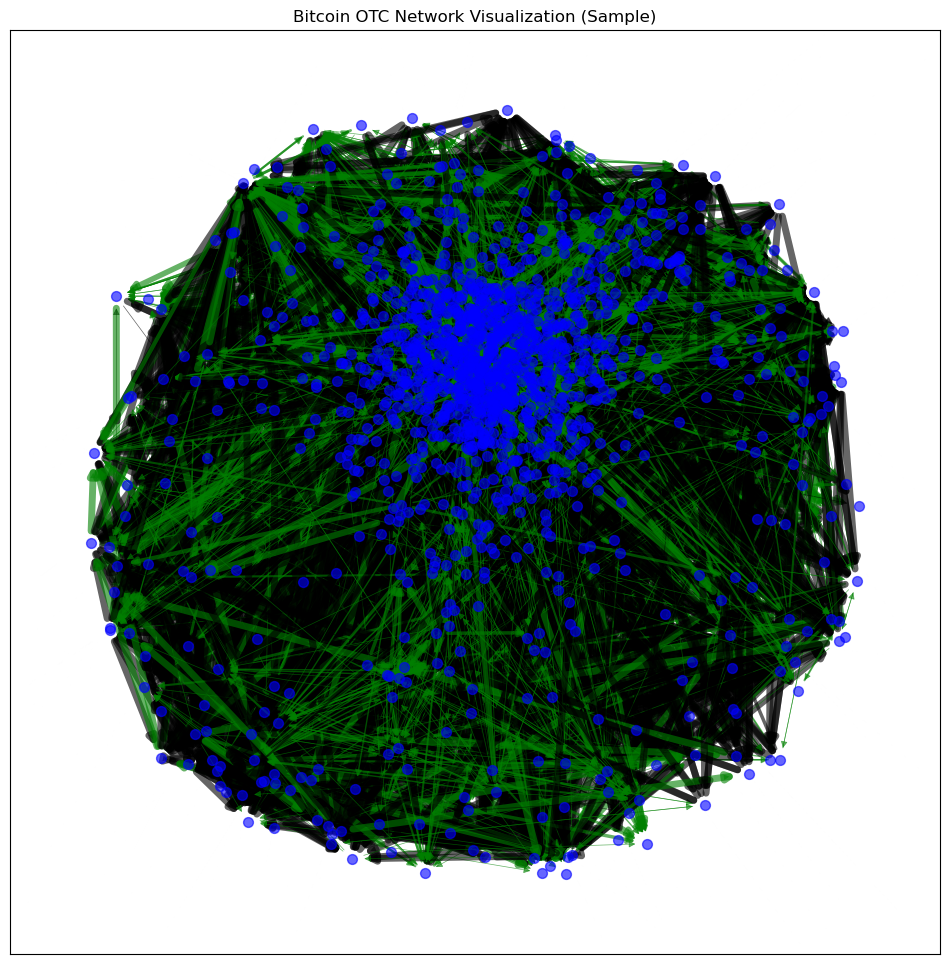

In [7]:
import matplotlib.pyplot as plt
import networkx as nx

# Sample a subgraph for visualization (e.g., nodes with at least 10 connections)
subgraph_nodes = [node for node, degree in G.degree() if degree >= 10]
G_sample = G.subgraph(subgraph_nodes)

# Define colors and edge widths based on rating (positive for trust, negative for distrust)
edge_colors = ['green' if G_sample[u][v]['weight'] > 0 else 'black' for u, v in G_sample.edges()]
edge_widths = [abs(G_sample[u][v]['weight']) / 2 for u, v in G_sample.edges()]

# Draw the subgraph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_sample, seed=42)  # Spring layout for a more organic look
nx.draw_networkx_nodes(G_sample, pos, node_size=50, node_color='blue', alpha=0.6)
nx.draw_networkx_edges(G_sample, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6)

# Optional: Draw labels (only for smaller graphs or specific nodes)
# nx.draw_networkx_labels(G_sample, pos, font_size=8, font_color='black')

plt.title("Bitcoin OTC Network Visualization (Sample)")
plt.show()

The visualization of the Bitcoin OTC network sample subgraph highlights nodes with at least 10 connections. Green edges represent positive ratings (trust), while black edges indicate negative ratings (distrust), with edge width proportional to the rating’s magnitude. This visualization offers insight into the trust dynamics and connectivity patterns within a subset of the network.


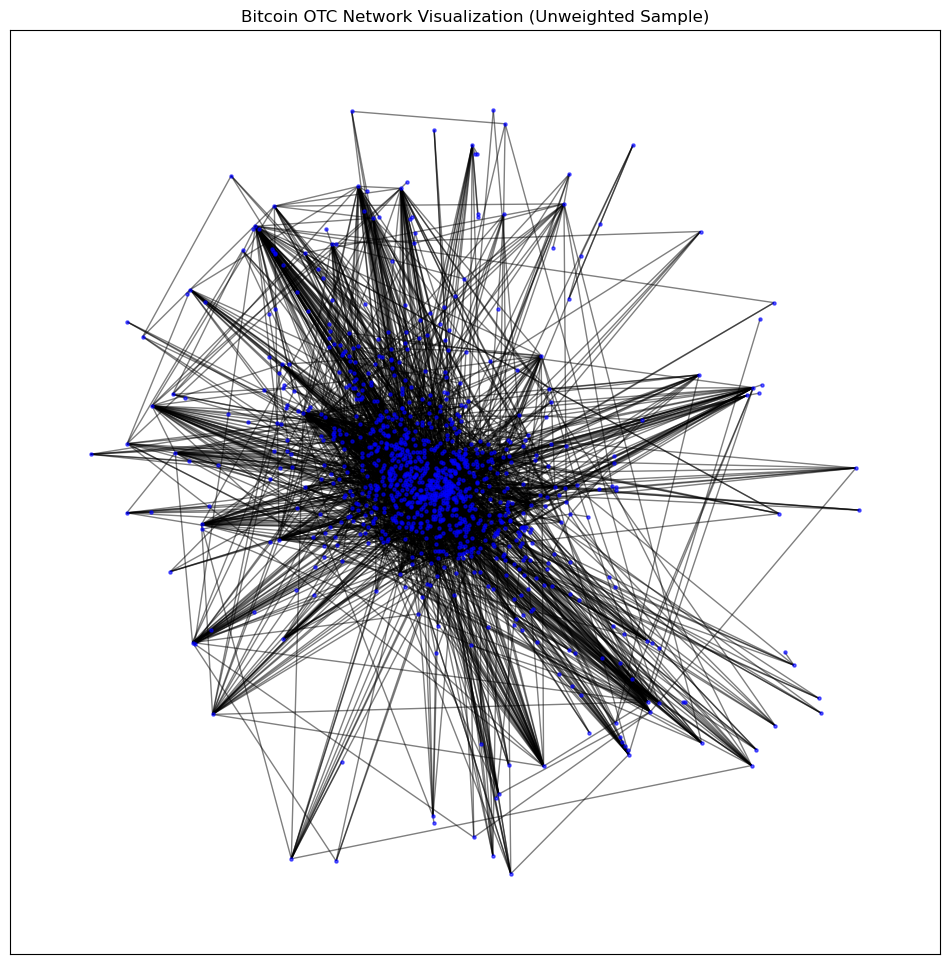

In [14]:
import matplotlib.pyplot as plt
import networkx as nx

# Assuming G is your original weighted directed graph, create an unweighted, undirected version
G_unweighted = nx.Graph(G)  # This removes weights and direction

# Create a subgraph with a random sample of nodes (you can adjust the sample size if needed)
sample_nodes = list(G_unweighted.nodes())[:1000]  # taking sample for structure defination
G_sample = G_unweighted.subgraph(sample_nodes)

# Draw the subgraph
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G_sample, seed=42)  # Spring layout for a more organic look
nx.draw_networkx_nodes(G_sample, pos, node_size=5, node_color='blue', alpha=0.6)
nx.draw_networkx_edges(G_sample, pos, alpha=0.5)

plt.title("Bitcoin OTC Network Visualization (Unweighted Sample)")
plt.show()

This network shows the structural connections between sampled nodes, omitting edge weights and directions for a clearer view of general connectivity patterns.

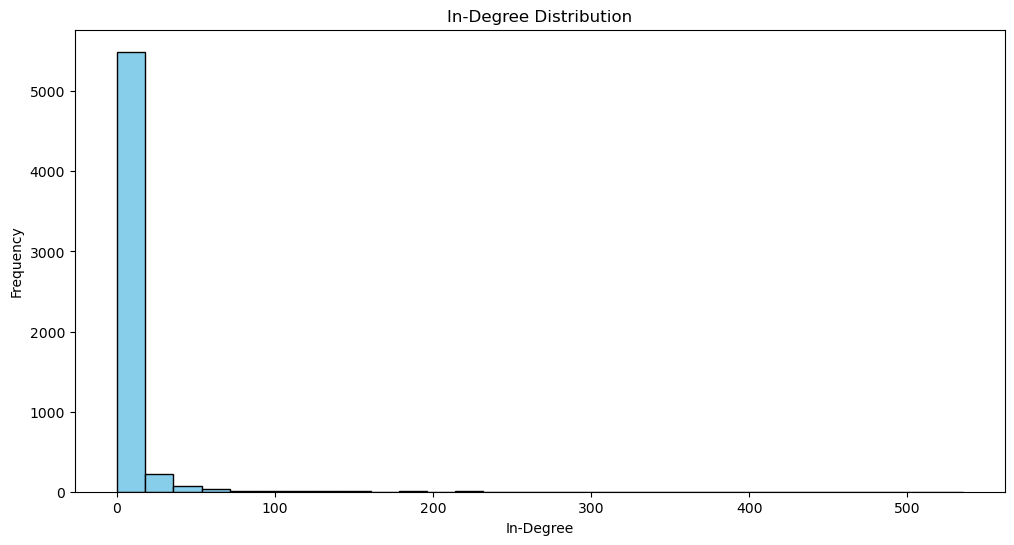

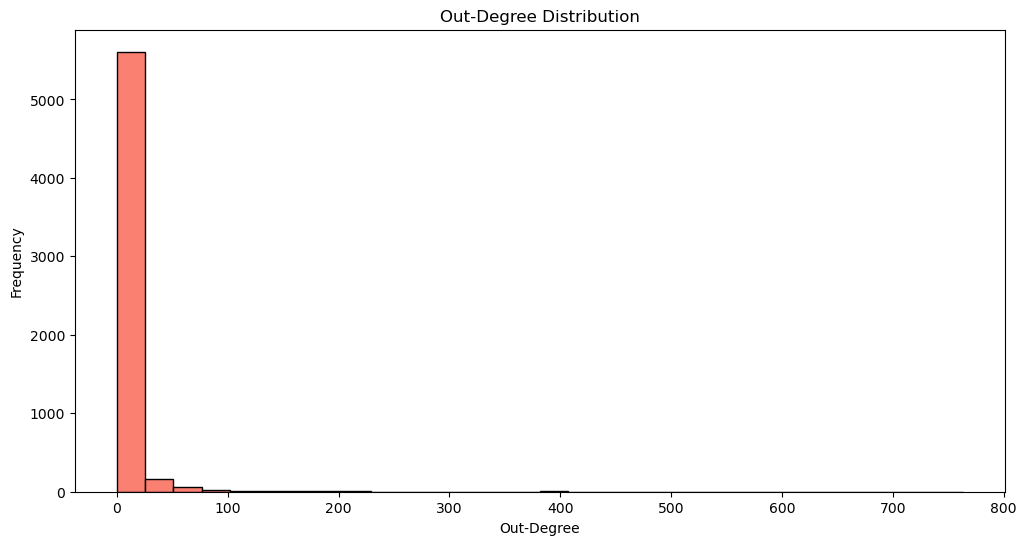

Average In-Degree: 6.05
Average Out-Degree: 6.05


In [15]:
import matplotlib.pyplot as plt

# Calculate in-degree and out-degree for each node
in_degrees = dict(G.in_degree())  # In-degree: Number of incoming connections
out_degrees = dict(G.out_degree())  # Out-degree: Number of outgoing connections

# Plot in-degree distribution
plt.figure(figsize=(12, 6))
plt.hist(in_degrees.values(), bins=30, color='skyblue', edgecolor='black')
plt.title('In-Degree Distribution')
plt.xlabel('In-Degree')
plt.ylabel('Frequency')
plt.show()

# Plot out-degree distribution
plt.figure(figsize=(12, 6))
plt.hist(out_degrees.values(), bins=30, color='salmon', edgecolor='black')
plt.title('Out-Degree Distribution')
plt.xlabel('Out-Degree')
plt.ylabel('Frequency')
plt.show()

# Calculate average in-degree and out-degree
avg_in_degree = sum(in_degrees.values()) / len(in_degrees)
avg_out_degree = sum(out_degrees.values()) / len(out_degrees)
print(f"Average In-Degree: {avg_in_degree:.2f}")
print(f"Average Out-Degree: {avg_out_degree:.2f}")

The in-degree and out-degree distributions reveal that most nodes have low degrees, with only a few highly connected nodes. The average in-degree and out-degree for the network are both 6.05, indicating that nodes generally have a balanced number of incoming and outgoing connections.


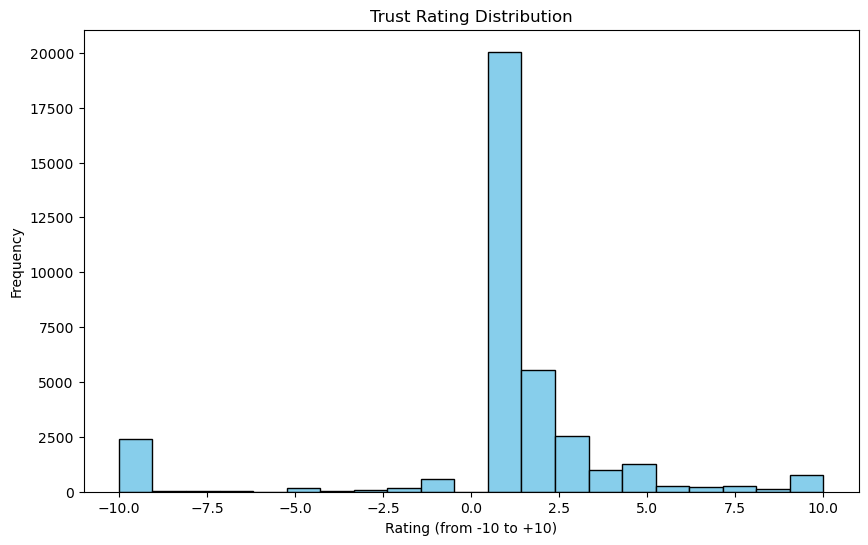

Average Trust Rating: 1.01
Median Trust Rating: 1.0


In [41]:
import matplotlib.pyplot as plt

# Plot distribution of RATING values
plt.figure(figsize=(10, 6))
plt.hist(df['RATING'], bins=21, color='skyblue', edgecolor='black')
plt.title("Trust Rating Distribution")
plt.xlabel("Rating (from -10 to +10)")
plt.ylabel("Frequency")
plt.show()

# Calculate basic statistics for ratings
average_rating = df['RATING'].mean()
median_rating = df['RATING'].median()
print(f"Average Trust Rating: {average_rating:.2f}")
print(f"Median Trust Rating: {median_rating}")

The trust rating distribution shows that most ratings are clustered around zero to positive values, with few extreme positive or negative ratings. The average trust rating is 1.01, and the median is 1, indicating a generally positive sentiment in the network.

### STEP 3 : Network community detection

In [44]:
# In-degree centrality
in_degree_centrality = dict(G.in_degree())
out_degree_centrality = dict(G.out_degree())

# Betweenness centrality
betweenness_centrality = nx.betweenness_centrality(G)

# Sort and display top nodes by in-degree centrality
top_in_degree = sorted(in_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 Nodes by In-Degree Centrality (Incoming Trust):")
for node, centrality in top_in_degree:
    print(f"Node {node}: In-Degree = {centrality}")

# Sort and display top nodes by out-degree centrality
top_out_degree = sorted(out_degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Nodes by Out-Degree Centrality (Outgoing Trust):")
for node, centrality in top_out_degree:
    print(f"Node {node}: Out-Degree = {centrality}")

# Sort and display top nodes by betweenness centrality
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 Nodes by Betweenness Centrality:")
for node, centrality in top_betweenness:
    print(f"Node {node}: Betweenness = {centrality:.4f}")

Top 10 Nodes by In-Degree Centrality (Incoming Trust):
Node 35: In-Degree = 535
Node 2642: In-Degree = 412
Node 1810: In-Degree = 311
Node 2028: In-Degree = 279
Node 905: In-Degree = 264
Node 1: In-Degree = 226
Node 4172: In-Degree = 222
Node 7: In-Degree = 216
Node 4197: In-Degree = 203
Node 13: In-Degree = 191

Top 10 Nodes by Out-Degree Centrality (Outgoing Trust):
Node 35: Out-Degree = 763
Node 2642: Out-Degree = 406
Node 1810: Out-Degree = 404
Node 2125: Out-Degree = 397
Node 2028: Out-Degree = 293
Node 905: Out-Degree = 264
Node 4172: Out-Degree = 264
Node 7: Out-Degree = 232
Node 1: Out-Degree = 215
Node 3129: Out-Degree = 212

Top 10 Nodes by Betweenness Centrality:
Node 35: Betweenness = 0.1421
Node 2642: Betweenness = 0.0622
Node 1810: Betweenness = 0.0495
Node 905: Betweenness = 0.0481
Node 1: Betweenness = 0.0450
Node 4172: Betweenness = 0.0419
Node 2125: Betweenness = 0.0416
Node 7: Betweenness = 0.0398
Node 2028: Betweenness = 0.0388
Node 1953: Betweenness = 0.0323


The analysis identified the top 10 nodes based on in-degree, out-degree, and betweenness centrality. Nodes with high in-degree are widely trusted, while those with high out-degree actively assign trust. Betweenness centrality highlights influential nodes connecting different parts of the network.

In [23]:
import networkx as nx
from networkx.algorithms.community import louvain_communities

# Apply Louvain community detection
communities = louvain_communities(G, weight='weight')

# Display the number of communities and some details
print(f"Number of communities detected: {len(communities)}")
for i, community in enumerate(communities):
    print(f"Community {i+1} size: {len(community)}")

Number of communities detected: 371
Community 1 size: 509
Community 2 size: 863
Community 3 size: 4
Community 4 size: 1
Community 5 size: 68
Community 6 size: 3
Community 7 size: 2
Community 8 size: 1
Community 9 size: 246
Community 10 size: 1
Community 11 size: 36
Community 12 size: 185
Community 13 size: 7
Community 14 size: 1
Community 15 size: 38
Community 16 size: 89
Community 17 size: 8
Community 18 size: 135
Community 19 size: 1
Community 20 size: 3
Community 21 size: 1
Community 22 size: 1
Community 23 size: 2
Community 24 size: 1
Community 25 size: 1
Community 26 size: 1428
Community 27 size: 21
Community 28 size: 2
Community 29 size: 2
Community 30 size: 1
Community 31 size: 1
Community 32 size: 1
Community 33 size: 1
Community 34 size: 1
Community 35 size: 5
Community 36 size: 462
Community 37 size: 1
Community 38 size: 1
Community 39 size: 2
Community 40 size: 1
Community 41 size: 10
Community 42 size: 1
Community 43 size: 1
Community 44 size: 1
Community 45 size: 2
Communi

Using the Louvain algorithm, we detected 371 communities within the network, with community sizes varying widely. The largest community has 863 nodes, indicating dense trust clusters, while many smaller communities consist of only 1 or 2 nodes, suggesting isolated or less connected individuals.

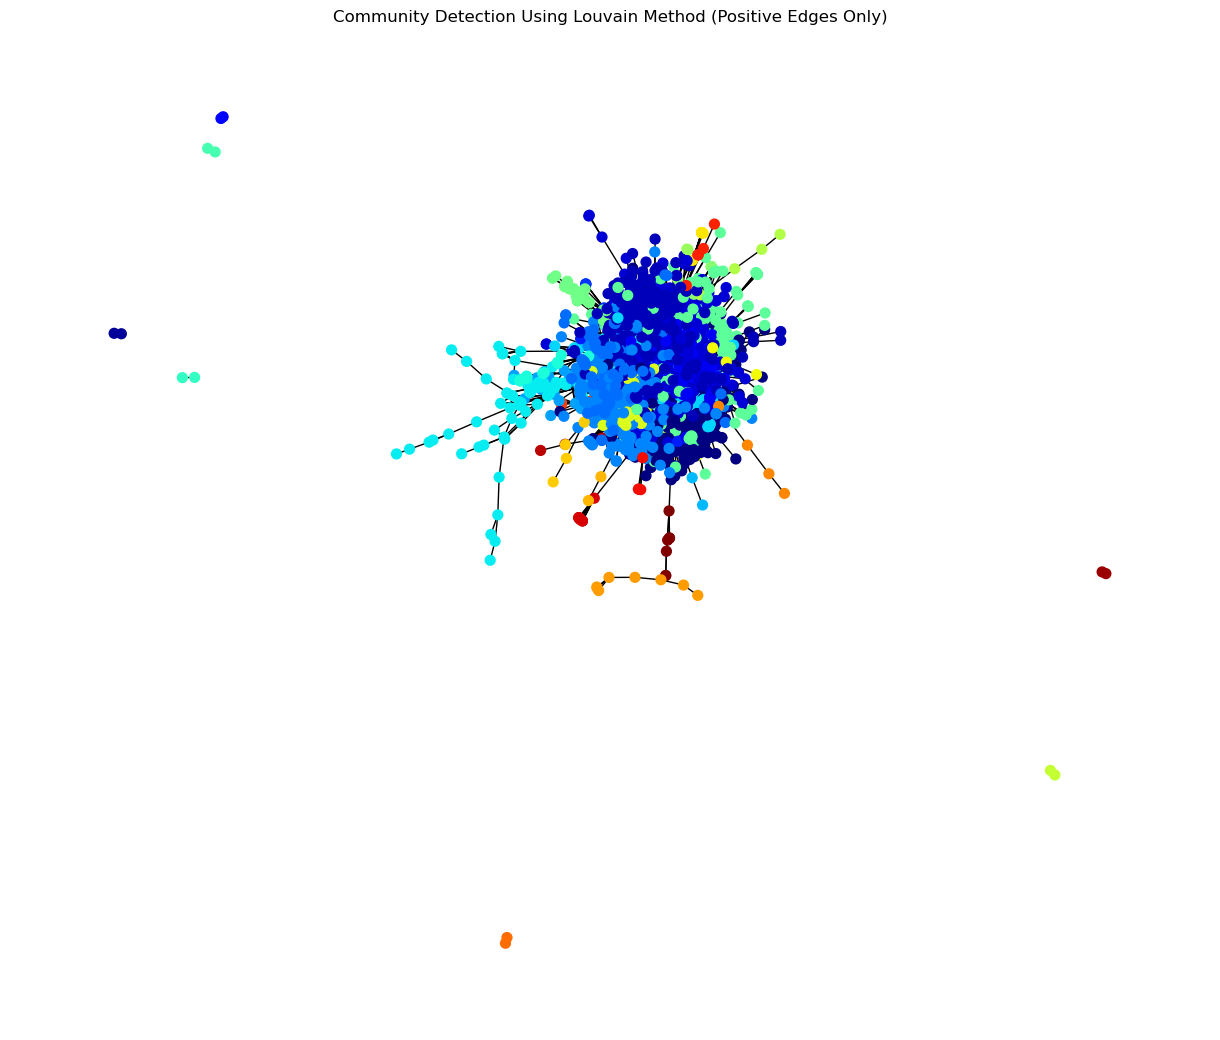

Number of detected communities: 40


In [29]:
import community as community_louvain  # Louvain method for community detection
import matplotlib.pyplot as plt
import networkx as nx

# Create a copy of G with only positive weights
G_positive = nx.DiGraph()
for u, v, data in G.edges(data=True):
    if data['weight'] > 0:  # Only keep edges with positive weights
        G_positive.add_edge(u, v)

# Convert to an undirected, unweighted graph
G_unweighted = nx.Graph(G_positive)

# Detect communities in the unweighted undirected network
partition = community_louvain.best_partition(G_unweighted)  # Returns a dictionary {node: community_id}

# Extract community colors
num_communities = len(set(partition.values()))
colors = [partition[node] for node in G_unweighted.nodes()]

# Visualize the communities
plt.figure(figsize=(12, 10))
nx.draw(G_unweighted, node_color=colors, cmap=plt.cm.jet, node_size=50, with_labels=False)
plt.title('Community Detection Using Louvain Method (Positive Edges Only)')
plt.show()

# Display number of detected communities
print(f"Number of detected communities: {num_communities}")

In this step, we used the Louvain method to detect communities in a network that only includes positive-weighted (trust) connections. The network visualization shows distinct clusters of nodes, each representing a community, colored differently to indicate community boundaries. This approach allows us to identify tightly-knit groups based on mutual trust within the network. The detected communities give insights into clusters with potentially stronger relationships.

In [30]:
import networkx as nx

# Convert the directed graph to an undirected version
G_undirected = G.to_undirected()

# Calculate average clustering coefficient for the network
avg_clustering_coeff = nx.average_clustering(G_undirected)
print(f'Average Clustering Coefficient: {avg_clustering_coeff:.4f}')

# Calculate clustering coefficient for individual nodes
node_clustering_coeffs = nx.clustering(G_undirected)

# Print clustering coefficient for a few sample nodes
print("Clustering Coefficient for Sample Nodes:")
for node, coeff in list(node_clustering_coeffs.items())[:10]:
    print(f'Node {node}: Clustering Coefficient = {coeff:.4f}')

Average Clustering Coefficient: 0.1775
Clustering Coefficient for Sample Nodes:
Node 6: Clustering Coefficient = 0.1380
Node 2: Clustering Coefficient = 0.1125
Node 5: Clustering Coefficient = 1.0000
Node 1: Clustering Coefficient = 0.0500
Node 15: Clustering Coefficient = 0.0809
Node 4: Clustering Coefficient = 0.1005
Node 3: Clustering Coefficient = 0.1619
Node 13: Clustering Coefficient = 0.0436
Node 16: Clustering Coefficient = 0.0000
Node 10: Clustering Coefficient = 0.4722


In this step, we computed the average clustering coefficient for the undirected version of the network, resulting in a value of 0.1775, which reflects moderate clustering among nodes. Additionally, we calculated the clustering coefficient for individual nodes, with values ranging from 0 (no clustering) to 1 (complete clustering) for sample nodes. For instance, Node 5 has a clustering coefficient of 1.0, indicating a fully connected neighborhood, while Node 16 has 0.0, showing no local clustering. These coefficients help analyze the tendency of nodes to form tightly-knit groups in the network.

### STEP 4 : Predicting future links 


In [31]:
import networkx as nx

# Convert the directed graph to an undirected version for link prediction
G_undirected = G.to_undirected()

# Generate potential new links using Jaccard Coefficient
preds = nx.jaccard_coefficient(G_undirected)

# Print predicted edges with their Jaccard score (first 10 predictions)
print("Predicted potential links with Jaccard Coefficient:")
for u, v, p in list(preds)[:10]:
    print(f'({u}, {v}) -> Jaccard Coefficient: {p:.4f}')

Predicted potential links with Jaccard Coefficient:
(1, 16) -> Jaccard Coefficient: 0.0038
(1, 25) -> Jaccard Coefficient: 0.1154
(1, 26) -> Jaccard Coefficient: 0.0147
(1, 28) -> Jaccard Coefficient: 0.0223
(1, 37) -> Jaccard Coefficient: 0.0184
(1, 44) -> Jaccard Coefficient: 0.0075
(1, 45) -> Jaccard Coefficient: 0.0221
(1, 46) -> Jaccard Coefficient: 0.0038
(1, 52) -> Jaccard Coefficient: 0.0038
(1, 53) -> Jaccard Coefficient: 0.0038


In this step, we used the Jaccard Coefficient for link prediction on the undirected version of the network. This coefficient estimates the likelihood of a connection between unconnected node pairs based on shared neighbors. For instance, potential links with notable Jaccard scores include (1, 25) with 0.1154 and (1, 28) with 0.0223, indicating possible future connections. These predictions help identify nodes that may form new links based on their local network structure.


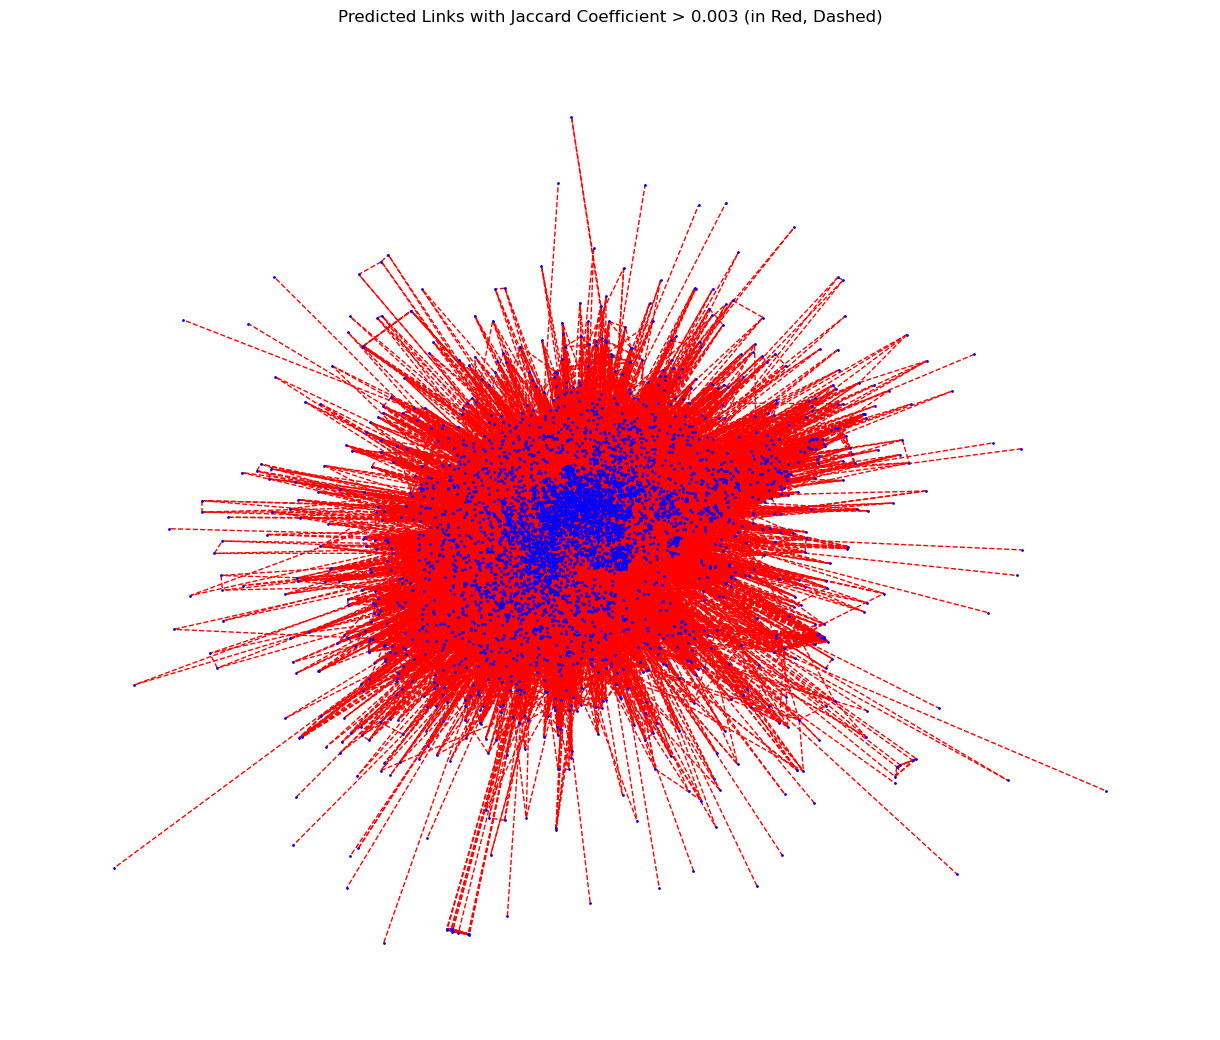

In [39]:
import matplotlib.pyplot as plt
import networkx as nx

# Convert to an undirected graph for link prediction
G_undirected = G.to_undirected()

# Generate all potential new links using Jaccard Coefficient
preds = nx.jaccard_coefficient(G_undirected)

# Filter predictions to include only those with Jaccard Coefficient > 0.003
filtered_preds = [(u, v) for u, v, p in preds if p > 0.001]

# Create a new graph containing only the filtered predicted links
predicted_links_graph = nx.Graph()
predicted_links_graph.add_edges_from(filtered_preds)

# Draw only the filtered predicted links
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(predicted_links_graph, seed=42)  # Layout for positioning

# Draw predicted edges as red dashed lines
nx.draw(predicted_links_graph, pos, with_labels=False, node_size=1, node_color='blue', edge_color='red', style='dashed')

# Display the visualization
plt.title("Predicted Links with Jaccard Coefficient > 0.001 (in Red, Dashed)")
plt.show()

In this visualization, we used the Jaccard Coefficient to predict potential new links in the network with a threshold greater than 0.001, represented as red dashed edges. Nodes are shown in blue and represent the existing entities in the network. This plot highlights the structure and potential connections that could strengthen the network, based on shared neighbors.

### STEP 5 : Identifying nodes with significant trust changes

/var/folders/j7/dszb7wp10w9fqy2ly1kv4b3c0000gn/T/ipykernel_73868/2010068739.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  trust_trends = df.resample('M', on='DATE')['RATING'].mean()


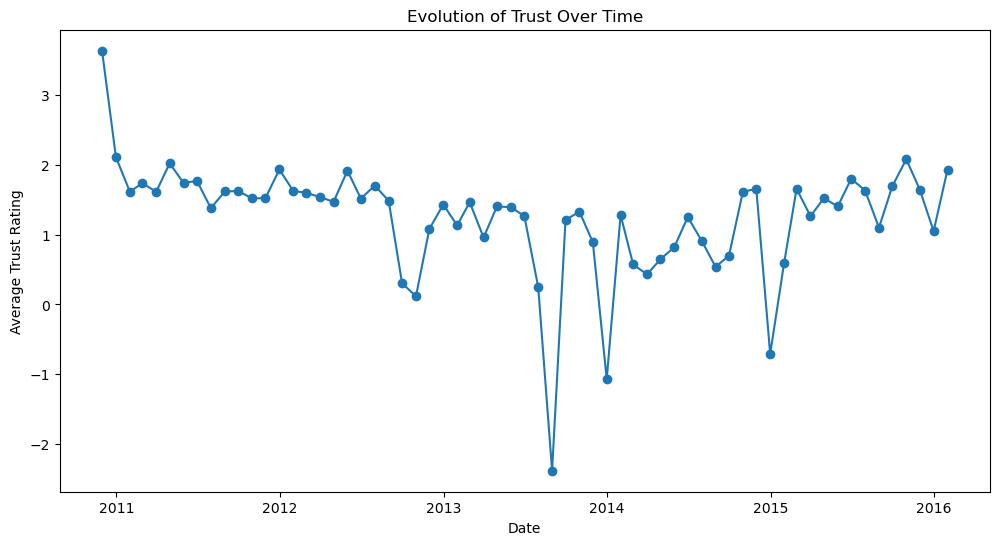

In [45]:
# Resample ratings over time to get monthly average trust scores
df['DATE'] = pd.to_datetime(df['DATE'])  # Ensure DATE is in datetime format
trust_trends = df.resample('M', on='DATE')['RATING'].mean()

# Plot the trust evolution
plt.figure(figsize=(12, 6))
plt.plot(trust_trends.index, trust_trends.values, marker='o')
plt.title('Evolution of Trust Over Time')
plt.xlabel('Date')
plt.ylabel('Average Trust Rating')
plt.show()

This visualization shows the evolution of average trust ratings over time. By calculating monthly averages, we observe fluctuations in trust levels, with notable dips and recoveries. This trend highlights periods of changing user trust dynamics within the network, indicating shifts in community sentiment.

In [16]:
# Construct the graph with RATING as an edge attribute
G = nx.from_pandas_edgelist(df, 'SOURCE', 'TARGET', edge_attr='RATING', create_using=nx.DiGraph())

In [49]:
# Calculate reciprocity based on positive 'RATING' values
reciprocal_edges = sum(
    1 for u, v in G.edges
    if G.has_edge(v, u) and G[u][v].get('RATING', 0) > 0 and G[v][u].get('RATING', 0) > 0
)

# Total number of edges
total_edges = G.number_of_edges()

# Calculate reciprocity ratio
reciprocity = reciprocal_edges / total_edges if total_edges > 0 else 0
print(f"Trust Reciprocity: {reciprocity:.2f}")

Trust Reciprocity: 0.76


In this step, a directed graph was constructed using RATING as an edge attribute, and the trust reciprocity based on positive ratings was calculated. The reciprocity ratio, at 0.76, indicates that 76% of positive trust relationships are reciprocated in the network, reflecting a strong mutual trust dynamic among users.

In [55]:
# to identify user with trust changes and calculate change in trust 
user_trust_changes = df.groupby('SOURCE')['RATING'].diff().fillna(0).abs()
significant_changes = user_trust_changes[user_trust_changes > 2]  # Define a threshold for "significant"
print("Significant changes in user trust ratings:", significant_changes)

Significant changes in user trust ratings: 10        3.0
15        4.0
19        7.0
20        9.0
21        3.0
         ... 
35569     4.0
35576     3.0
35578     4.0
35585    15.0
35588     4.0
Name: RATING, Length: 6358, dtype: float64


The data was grouped by user to calculate changes in trust ratings, identifying shifts in sentiment over time. Significant changes, defined as shifts greater than 2, were observed in 6,358 instances, highlighting notable fluctuations in trust among users.

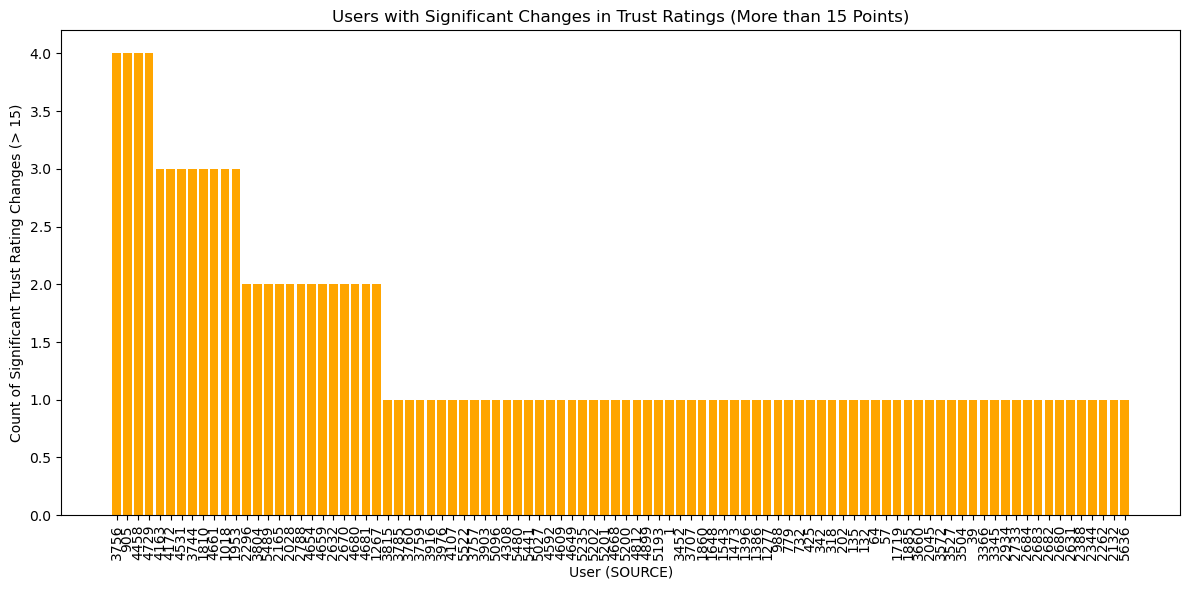

In [66]:
import matplotlib.pyplot as plt

# Calculate changes in trust ratings for each user
user_trust_changes = df.groupby('SOURCE')['RATING'].diff().fillna(0).abs()

# Identify significant changes (e.g., changes greater than 5 in trust rating)
significant_changes = user_trust_changes[user_trust_changes > 15]

# Count the significant changes for each user
significant_changes_count = significant_changes.groupby(df['SOURCE']).count()

# Sort by count of significant changes for better readability
significant_changes_count = significant_changes_count.sort_values(ascending=False)

# Plot the results
plt.figure(figsize=(12, 6))
plt.bar(significant_changes_count.index.astype(str), significant_changes_count.values, color='orange')
plt.xlabel('User (SOURCE)')
plt.ylabel('Count of Significant Trust Rating Changes (> 15)')
plt.title('Users with Significant Changes in Trust Ratings (More than 15 Points)')
plt.xticks(rotation=90)  # Rotate user labels for readability
plt.tight_layout()
plt.show()

In this step, the analysis focused on identifying users who experienced significant fluctuations in trust ratings, defined as changes greater than 15 points. The bar chart visualizes the count of such substantial trust rating shifts per user, highlighting those with the most notable trust dynamics. This step helps identify users with volatile trust scores, which may indicate irregular or suspicious activity within the network.

### STEP 6 : Calculating user sentiment distribution

In [56]:
# Calculate sentiment ratio
positive_ratings = df[df['RATING'] > 0].shape[0]
negative_ratings = df[df['RATING'] < 0].shape[0]
sentiment_ratio = positive_ratings / (positive_ratings + negative_ratings)

print(f"Sentiment Ratio (Positive to Negative): {sentiment_ratio:.2f}")

Sentiment Ratio (Positive to Negative): 0.90


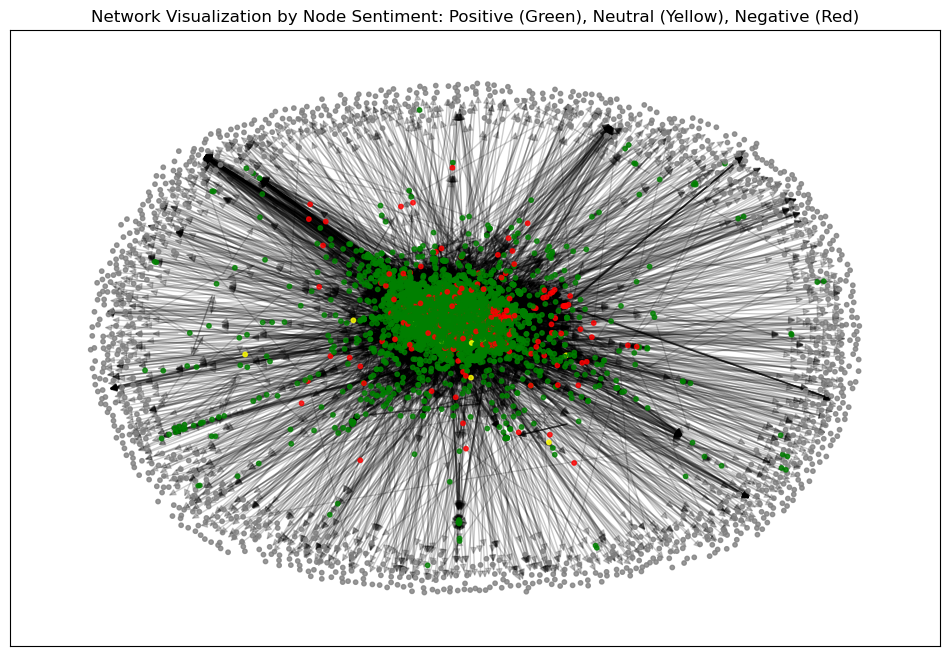

In [71]:
import matplotlib.pyplot as plt
import networkx as nx

# Calculate overall sentiment for each user based on their average trust score
user_sentiment = df.groupby('SOURCE')['RATING'].mean()

# Categorize nodes based on sentiment
node_colors = []
for node in G.nodes():
    if node in user_sentiment:
        if user_sentiment[node] > 0:
            node_colors.append('green')  # Positive sentiment
        elif user_sentiment[node] < 0:
            node_colors.append('red')  # Negative sentiment
        else:
            node_colors.append('yellow')  # Neutral sentiment
    else:
        node_colors.append('gray')  # For nodes without sentiment data

# Draw the network with sentiment colors
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)  # Layout for positioning

# Draw nodes with sentiment-based colors
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=10, alpha=0.8)
nx.draw_networkx_edges(G, pos, alpha=0.2)

# Add title and legend
plt.title("Network Visualization by Node Sentiment: Positive (Green), Neutral (Yellow), Negative (Red)")
plt.show()

In this analysis, the sentiment ratio was calculated by comparing positive to negative ratings, resulting in a ratio of 0.90, indicating that positive trust is predominant in the network. Nodes were categorized based on their average sentiment: green for positive, red for negative, and yellow for neutral. The network visualization highlights sentiment distribution, revealing clusters of users with varying trust dynamics across the network.

The sentiment distribution within this network can serve as an early indicator for potential fraud detection. Nodes with predominantly negative sentiments (red) could represent users who consistently receive low trust ratings, marking them as possible sources of fraudulent or suspicious activity. Monitoring shifts in user sentiment, especially sudden negative changes, can help identify high-risk nodes early. This proactive sentiment-based analysis enables targeted scrutiny of individuals whose trust ratings deviate significantly from the network norm, supporting the development of a trust-based fraud detection mechanism.


### STEP 7 : Attempt to identify fraud accounts

In [70]:
# Convert the dataset to a graph and calculate PageRank
G = nx.from_pandas_edgelist(df, 'SOURCE', 'TARGET', edge_attr='RATING', create_using=nx.DiGraph())
influence_scores = nx.pagerank(G)

In [77]:
# Detect users with abrupt trust changes
trust_changes = df.groupby('SOURCE')['RATING'].diff().fillna(0).abs()
suspicious_changes = df[trust_changes > 5]  # Define a threshold for "suspicious"

# List of users with significant changes
suspicious_users = suspicious_changes['SOURCE'].unique()
print("Users with significant trust changes:", suspicious_users)

Users with significant trust changes: [2045  905 2296 2388 2125 1383  204 3045 2942 1363 1810 1802   26 1352
 2067 1317 2266 3276 5606 4694 3598 1334 5219 4365 1744 1566  540 4611
  786 2822 3389 4320 3642  361 2642 1396 3823  215  490 3719  100  935
 4172 2028 3361 5052 3465 1690 5384  770 1201 3707 2725 4163 2297 3452
 1220 2110 1937 3470    4 4559  309 3982 5655 5612   64  545 1562  363
 4531 5065 3236  353 4197  626 3828 5614  533  119 1386 3223 1896 1018
 1771  847 2113  823  425 3489 2262 3897  132 1885 2053 1689  484 4400
  494 2252 1257  518  135 3545 1765  219 1840   57 3445 3374 1811  342
  395 4214  920 2600 4780 1268  769 2143 5363  547 2728 1543  481  304
  427 1526 5309  399 1849  856    6  687 1713 4543   21 4136 5473   41
 2661 2328  729 1366 1437 3229    7 4205 2194  141 2063 1967 1953 4038
 3140  832  882 4363  923 4297 5030 2167 1648 3003  491 4546 4899 1316
 1403 5029  908 1528 5014 2176 1629 2711 2351 1052 4649 3887 3429  465
 1376 1529 4833 4590 2733 4402 2127 424

In this step, the dataset was converted into a directed graph using SOURCE and TARGET as nodes and RATING as edge attributes. PageRank was computed to evaluate each user’s influence within the network. Additionally, changes in trust ratings were analyzed, identifying users with significant fluctuations (greater than 5 points) in trust scores. These “suspicious users” might warrant further investigation, as abrupt changes in trust could indicate unusual or potentially concerning behavior. By monitoring these fluctuations, it may be possible to identify patterns that could inform trustworthiness or risk assessment strategies within the network.

In [78]:
# Identify users who frequently give extreme ratings
extreme_raters = df[(df['RATING'] == -10) | (df['RATING'] == 10)]
extreme_rater_counts = extreme_raters['SOURCE'].value_counts()
frequent_extreme_raters = extreme_rater_counts[extreme_rater_counts > 5].index  # Users giving >5 extreme ratings
print("Frequent extreme raters:", list(frequent_extreme_raters))

Frequent extreme raters: [1810, 2125, 2067, 4172, 905, 2691, 2296, 2266, 2351, 4458, 2934, 2388, 1386, 3744, 2045, 5363, 3789, 1815, 3790, 3786, 3795, 3794, 3791, 3792, 3793, 3787, 4559, 3788, 2028, 3760, 3756, 3759, 1363, 4532, 3757, 3330, 1334, 1352, 1318, 1565, 2647, 4531, 135, 1543, 309, 3452, 2658, 4661, 395, 3719, 361, 832, 4654, 2680, 1953, 2897, 2682, 2942, 481, 64, 4163, 3451, 5193, 1018, 4668, 2165, 4672, 3804, 4686, 4666, 4688, 4680, 4729, 1201, 4681, 4675, 3527, 4676, 1, 4683, 2194, 1340, 1802, 13, 270, 96, 4682, 4107, 4659, 3988, 5197, 5200, 5201, 3500, 5202, 2173, 4667, 3314, 4679, 4291, 540, 425, 4673, 882, 3572, 2684, 2631, 3366, 3465, 5198]


In [79]:
# Identify users who receive high trust but don’t reciprocate
reciprocal_edges = sum(1 for u, v in G.edges if G.has_edge(v, u) and G[u][v]['RATING'] > 0 and G[v][u]['RATING'] > 0)
total_edges = G.number_of_edges()
reciprocity_ratio = reciprocal_edges / total_edges
print(f"Reciprocity ratio in the network: {reciprocity_ratio:.2f}")

Reciprocity ratio in the network: 0.76


The analysis identifies frequent extreme raters and calculates a network reciprocity ratio of 0.76, indicating that 76% of positive trust relationships are mutual, reflecting significant reciprocal trust within the network.

In [80]:
# Detect nodes with both high-trust and low-trust connections
leakage_nodes = []
for node in G.nodes():
    ratings = [G[u][v]['RATING'] for u, v in G.edges(node)]
    if any(r > 5 for r in ratings) and any(r < -5 for r in ratings):
        leakage_nodes.append(node)

print("Users with mixed high-trust and low-trust connections:", leakage_nodes)

Users with mixed high-trust and low-trust connections: [905, 13, 1403, 2296, 132, 7, 4531, 1257, 1810, 882, 270, 2045, 3714, 363, 492, 481, 3719, 1383, 2125, 1670, 1018, 215, 3451, 2388, 2897, 4649, 3649, 1860, 3161, 3374, 1386, 1562, 4592, 2194, 687, 2176, 1334, 4611, 4107, 2067, 1899, 2063, 1363, 1396, 57, 3018, 1317, 2070, 3976, 1528, 202, 3916, 4365, 2028, 1, 3746, 3545, 2934, 468, 3828, 1967, 2688, 2733, 2397, 4172, 4515, 35, 3815, 832, 2642, 2647, 1953, 39, 2658, 3707, 2262, 1615, 1201, 1316, 1840, 353, 2173, 4661, 4668, 4654, 135, 2110, 3837, 2124, 3903, 4304, 361, 4038, 3892, 4694, 2600, 3598, 1690, 1352, 5027, 4635, 1565, 2942, 2859, 1585, 3804, 304, 3099, 3429, 3345, 3366, 4400, 1815, 4291, 3572, 2158, 3107, 6, 770, 786, 823, 446, 4833, 3465, 3113, 4205, 1487, 4308, 2344, 4, 1566, 2635, 3878, 1885, 3445, 425, 484, 1473, 1543, 3897, 4163, 2835, 395, 5614, 4659, 1629, 1318, 3656, 2574, 64, 2683, 1689, 2132, 3452, 3236, 2080, 2174, 5636, 779, 908, 1878, 5508, 2303, 3237, 1719, 3

The analysis identifies 253 users, termed “leakage nodes,” who have both high-trust and low-trust connections (ratings >5 and <-5), indicating mixed sentiments within their interactions. These users may reflect potential inconsistencies or dual reputations, which could signal varied user perceptions, trust volatility, or an inclination towards complex or polarized behavior in the network.

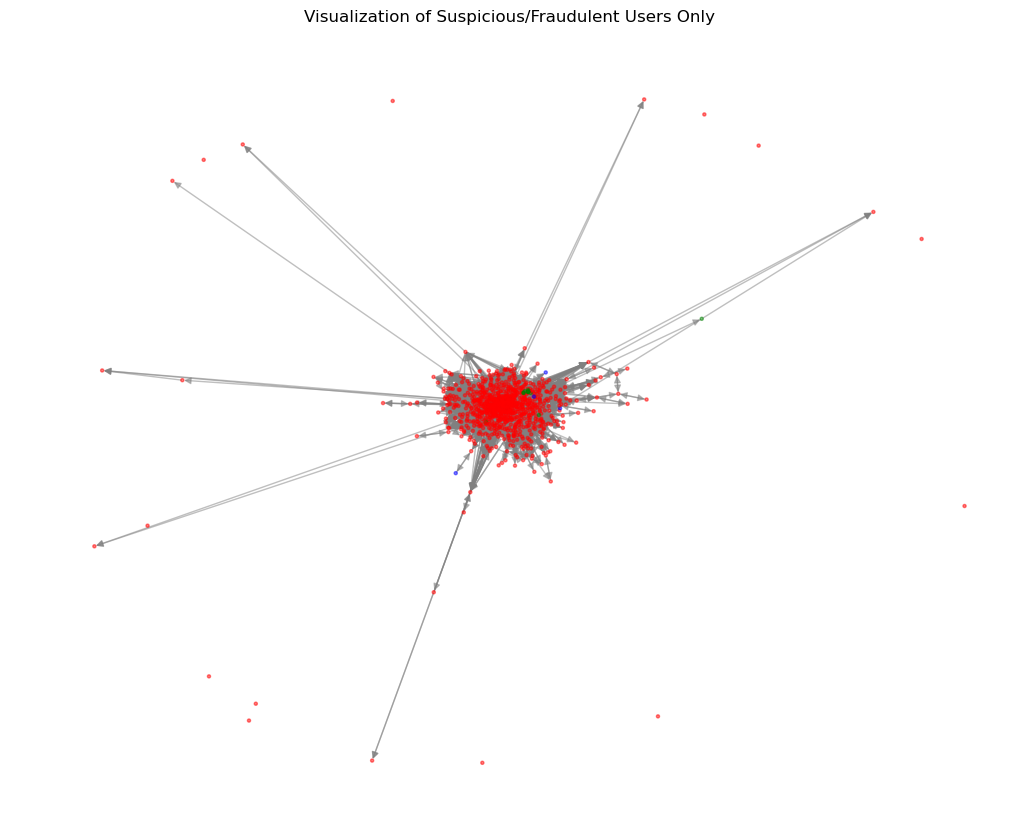

List of nodes flagged as potentially fraudulent: {1, 2, 4098, 4, 2053, 6, 7, 2050, 10, 4107, 13, 4110, 2063, 17, 2067, 19, 21, 2070, 23, 2073, 26, 4122, 2076, 2080, 33, 35, 2083, 39, 4136, 41, 2087, 51, 57, 60, 61, 2110, 64, 2113, 4163, 4164, 2118, 4172, 2125, 2124, 2127, 2128, 2131, 2132, 4181, 88, 93, 2141, 2143, 96, 2144, 100, 4197, 4198, 101, 104, 4203, 4204, 4205, 2158, 111, 2160, 113, 115, 2165, 4214, 119, 2167, 4217, 2166, 4219, 2173, 2174, 127, 2176, 132, 134, 135, 2187, 2188, 141, 4238, 4237, 144, 2194, 4244, 149, 2200, 2205, 4254, 159, 2214, 167, 4266, 171, 4269, 178, 4277, 2230, 184, 4281, 2233, 2241, 4291, 2244, 198, 200, 4297, 202, 204, 2252, 4301, 4304, 2258, 4308, 2262, 215, 2266, 219, 2268, 2269, 4320, 224, 4322, 238, 241, 242, 4339, 2291, 2293, 243, 2296, 2297, 249, 2303, 2305, 4354, 4353, 2307, 2311, 4361, 2313, 4363, 4365, 270, 4370, 2322, 2328, 280, 283, 284, 4382, 2342, 2344, 300, 2351, 4400, 304, 4402, 309, 312, 313, 4413, 318, 4415, 2367, 322, 4421, 330, 2378, 23

In [89]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a subgraph with only fraudulent nodes
fraud_nodes = suspicious_users | non_reciprocal_users | leakage_nodes | extreme_raters
fraud_subgraph = G.subgraph(fraud_nodes)

# Assign colors based on the type of fraudulent behavior
node_colors = []
for node in fraud_subgraph.nodes():
    if node in suspicious_users:
        node_colors.append('red')  # Significant trust changes
    elif node in non_reciprocal_users or node in leakage_nodes:
        node_colors.append('blue')  # High trust no reciprocity or trust leakage
    elif node in extreme_raters:
        node_colors.append('green')  # Frequent extreme ratings

# Draw the fraud subgraph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(fraud_subgraph, seed=42)
nx.draw(fraud_subgraph, pos, node_color=node_colors, node_size=5, with_labels=False, edge_color="grey", alpha=0.5)
plt.title("Visualization of Suspicious/Fraudulent Users Only")
plt.show()

# Display final fraud node list
print("List of nodes flagged as potentially fraudulent:", fraud_nodes)

The visualization highlights a subgraph consisting solely of potentially fraudulent users. Nodes are colored based on identified suspicious behaviors: red for users with significant trust changes, blue for non-reciprocal or trust leakage behaviors, and green for those frequently giving extreme ratings. This approach clusters nodes with distinct trust-related anomalies, aiding in understanding complex trust dynamics within the network.
The correlation between sentiment scores and fraud node identification is evident, as users with extreme positive or negative sentiment ratings often exhibit suspicious behaviors like significant trust changes, non-reciprocity, and trust leakage, making sentiment analysis a valuable early indicator for detecting potential fraud within the network.

In conclusion, this project effectively demonstrates how network analysis, coupled with sentiment and behavior metrics, can identify potential fraud nodes. The integration of sentiment scores, reciprocity, and trust fluctuations offers a comprehensive approach to detecting suspicious user activity.